# 01 — Análise Exploratória de Dados

**Dataset:** Telco Customer Churn (IBM) — 7.043 clientes × 33 colunas.

Este notebook responde a três perguntas:

1. **Como é o dado?** Tamanho, tipos, primeiras/últimas linhas.
2. **Qual a qualidade?** Nulos, duplicatas, outliers, problemas de tipo.
3. **O que ele nos diz sobre churn?** Distribuições, taxas de churn por nível, correlações com o target.

> Este notebook **não toma decisões de descarte** — só observa e documenta.
> As escolhas de imputação, encoding e remoção ficam no `02_data_prep.ipynb`,
> sustentadas pelos achados aqui. Política: nenhuma feature sai sem evidência.

## 1. Setup

In [1]:
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from churn.config import (
    SEED,
    TARGET_COLUMN,
    LEAKAGE_COLUMNS,
    EXPECTED_RAW_SHAPE,
)
from churn.data.loader import load_raw_data

warnings.filterwarnings('ignore', category=FutureWarning)
logging.basicConfig(level=logging.INFO, format='%(levelname)s [%(name)s] %(message)s')

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

In [2]:
df = load_raw_data()
df.shape

INFO [churn.data.loader] Loading raw data from D:\Projs\Churn-Prediction-ANN\data\raw\raw_data.xlsx


INFO [churn.data.loader] Loaded raw data: 7043 rows x 33 columns


INFO [churn.data.loader] Raw data schema validated successfully


(7043, 33)

## 2. Visão geral

Shape, primeiras e últimas linhas, tipos e estatísticas descritivas.

In [3]:
df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.tail(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,No,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

### 2.1 Estatísticas descritivas — numéricas

In [6]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


### 2.2 Estatísticas descritivas — categóricas

In [7]:
df.describe(include='object').T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


## 3. Qualidade dos dados

### 3.1 Nulos por coluna

In [8]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'missing_pct': missing_pct}).query('missing > 0')

,missing,missing_pct
Churn Reason,5174,73.46


### 3.2 Duplicatas

In [9]:
print('Linhas totalmente duplicadas:', df.duplicated().sum())
print('CustomerID duplicados:', df['CustomerID'].duplicated().sum())

Linhas totalmente duplicadas: 0
CustomerID duplicados: 0


### 3.3 `Total Charges` está como `object`

O dtype indica strings — provavelmente há registros não-numéricos. Vamos identificar quem são para entender o problema (a conversão definitiva fica no `02_data_prep`).

In [10]:
tc_numeric = pd.to_numeric(df['Total Charges'], errors='coerce')
n_failed = tc_numeric.isna().sum()
print(f'Linhas que falham na conversão para float: {n_failed}')

if n_failed > 0:
    failing = df[tc_numeric.isna()][['CustomerID', 'Tenure Months', 'Total Charges', 'Churn Value']]
    print('\nAmostra das linhas problemáticas:')
    display(failing.head(15))
    print('\nValor único(s) problemático(s):', df.loc[tc_numeric.isna(), 'Total Charges'].unique())

Linhas que falham na conversão para float: 11

Amostra das linhas problemáticas:


,CustomerID,Tenure Months,Total Charges,Churn Value
2234,4472-LVYGI,0,,0
2438,3115-CZMZD,0,,0
2568,5709-LVOEQ,0,,0
2667,4367-NUYAO,0,,0
2856,1371-DWPAZ,0,,0
4331,7644-OMVMY,0,,0
4687,3213-VVOLG,0,,0
5104,2520-SGTTA,0,,0
5719,2923-ARZLG,0,,0
6772,4075-WKNIU,0,,0



Valor único(s) problemático(s): [' ']


### 3.4 Cardinalidade das categóricas

In [11]:
obj_cols = df.select_dtypes(include='object').columns
card = pd.DataFrame({
    'n_unique': df[obj_cols].nunique().sort_values(ascending=False),
    'sample_values': [df[c].dropna().unique()[:5].tolist() for c in df[obj_cols].nunique().sort_values(ascending=False).index],
})
card

,n_unique,sample_values
CustomerID,7043,"[3668-QPYBK, 9237-HQITU, 9305-CDSKC, 7892-POOK..."
Total Charges,6531,"[108.15, 151.65, 820.5, 3046.05, 5036.3]"
Lat Long,1652,"[33.964131, -118.272783, 34.059281, -118.30742..."
City,1129,"[Los Angeles, Beverly Hills, Huntington Park, ..."
Churn Reason,20,"[Competitor made better offer, Moved, Competit..."
Payment Method,4,"[Mailed check, Electronic check, Bank transfer..."
Internet Service,3,"[DSL, Fiber optic, No]"
Device Protection,3,"[No, Yes, No internet service]"
Streaming Movies,3,"[No, Yes, No internet service]"
Contract,3,"[Month-to-month, Two year, One year]"


## 4. Target — `Churn Value`

             count    pct
Churn Value              
0             5174  73.46
1             1869  26.54


INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


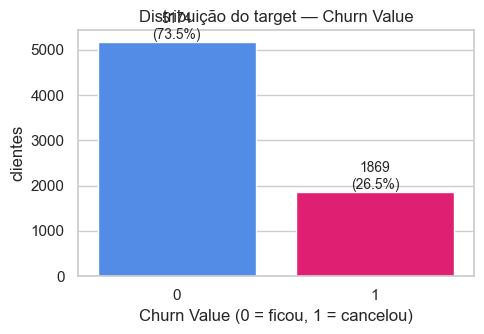

In [12]:
counts = df[TARGET_COLUMN].value_counts()
pct = df[TARGET_COLUMN].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': counts, 'pct': pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(data=df, x=TARGET_COLUMN, ax=ax, palette=['#3a86ff', '#ff006e'])
ax.set_title(f'Distribuição do target — {TARGET_COLUMN}')
ax.set_xlabel('Churn Value (0 = ficou, 1 = cancelou)')
ax.set_ylabel('clientes')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()

## 5. Análise de vazamento (target leakage)

Inspeção das colunas que **derivam do target** e devem sair antes do treino: `Churn Label`, `Churn Score`, `Churn Reason` e — para ser honesto — `CLTV` (CLTV é histórico, mas pode ter sido calculado *após* o churn no dataset).

### 5.1 `Churn Label` — duplicata textual do target

In [13]:
pd.crosstab(df['Churn Label'], df['Churn Value'], margins=True)

Churn Value,0,1,All
Churn Label,,,
No,5174,0,5174
Yes,0,1869,1869
All,5174,1869,7043


### 5.2 `Churn Score` — gerado por modelo IBM SPSS

Se o score já é uma predição do churn, ele é praticamente o target em outra escala. Vamos olhar a distribuição por classe e a AUC sozinha.

AUC de Churn Score isolado: 0.9417


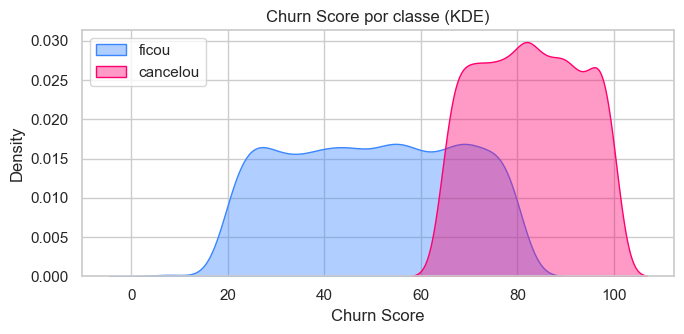

In [14]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(df['Churn Value'], df['Churn Score'])
print(f'AUC de Churn Score isolado: {auc_score:.4f}')

fig, ax = plt.subplots(figsize=(7, 3.5))
for v, label, color in [(0, 'ficou', '#3a86ff'), (1, 'cancelou', '#ff006e')]:
    sns.kdeplot(df[df['Churn Value'] == v]['Churn Score'], ax=ax, fill=True, alpha=0.4, label=label, color=color)
ax.set_title('Churn Score por classe (KDE)')
ax.set_xlabel('Churn Score'); ax.legend()
plt.tight_layout(); plt.show()

### 5.3 `Churn Reason` — só preenchido quando `Churn Value == 1`

In [15]:
leak_reason = df.groupby('Churn Value')['Churn Reason'].apply(lambda s: s.notna().mean() * 100).round(2)
leak_reason.to_frame('% preenchido')

,% preenchido
Churn Value,
0,0.0
1,100.0


### 5.4 `CLTV` — investigar se é proxy do target

CLTV é definido como predição de valor futuro. Se foi calculado corretamente (usando só features históricas), pode ser informativo. Se foi calculado *após* o trimestre, é leak.

AUC de -CLTV isolado: 0.5808


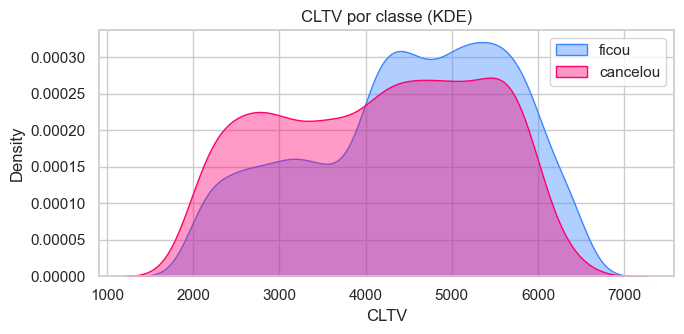

In [16]:
auc_cltv = roc_auc_score(df['Churn Value'], -df['CLTV'])  # CLTV alto -> menor churn -> sinal negativo
print(f'AUC de -CLTV isolado: {auc_cltv:.4f}')

fig, ax = plt.subplots(figsize=(7, 3.5))
for v, label, color in [(0, 'ficou', '#3a86ff'), (1, 'cancelou', '#ff006e')]:
    sns.kdeplot(df[df['Churn Value'] == v]['CLTV'], ax=ax, fill=True, alpha=0.4, label=label, color=color)
ax.set_title('CLTV por classe (KDE)')
ax.set_xlabel('CLTV'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Análise das numéricas

Para cada coluna numérica genuinamente contínua: histograma, KDE, boxplot por classe e classificação de simetria.

In [17]:
# Defino aqui as numéricas 'genuínas' do ponto de vista de modelagem.
# Excluo Count (constante=1), Zip Code (categórico apesar do int), e
# Latitude/Longitude (geo, tratados na seção 8).
df_eda = df.copy()
df_eda['Total Charges'] = pd.to_numeric(df_eda['Total Charges'], errors='coerce')

NUM_COLS = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Score']
print('Numéricas analisadas:', NUM_COLS)

Numéricas analisadas: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Score']


INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


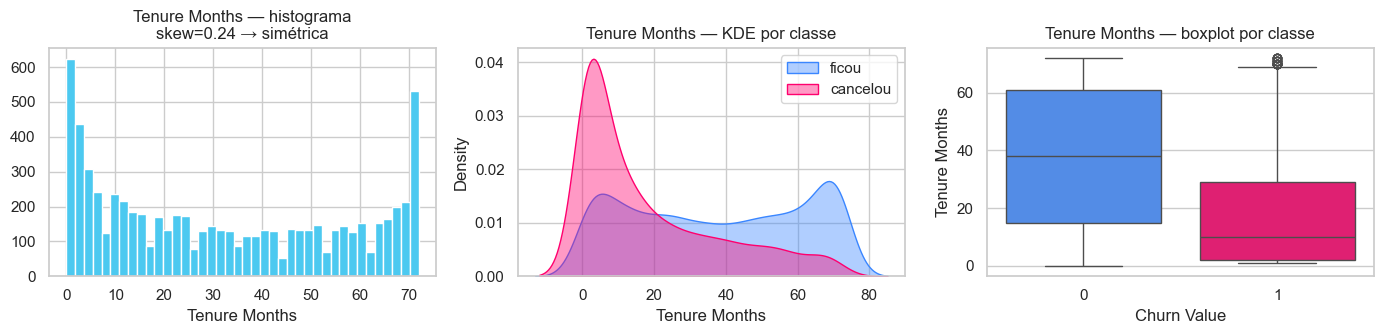

INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


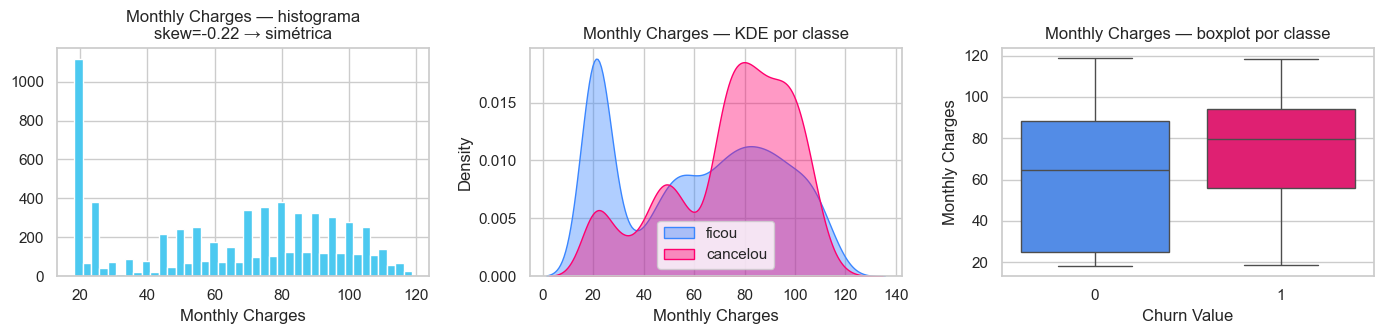

INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


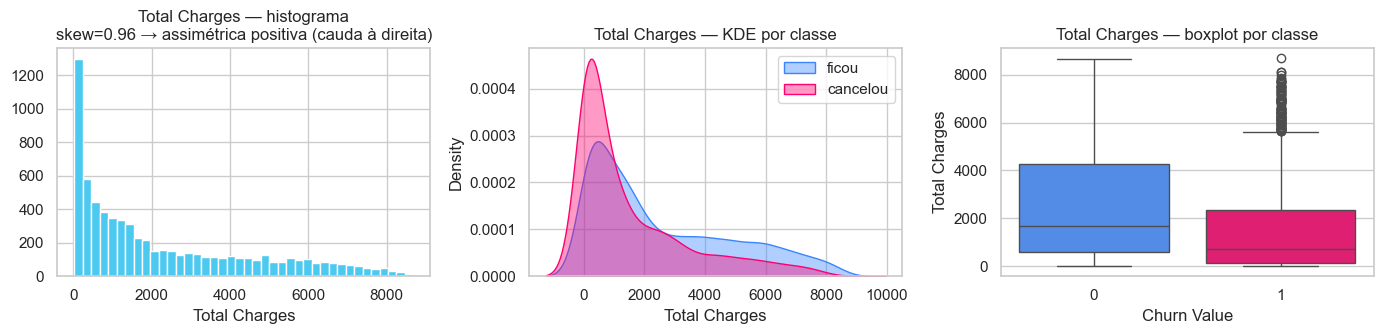

INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


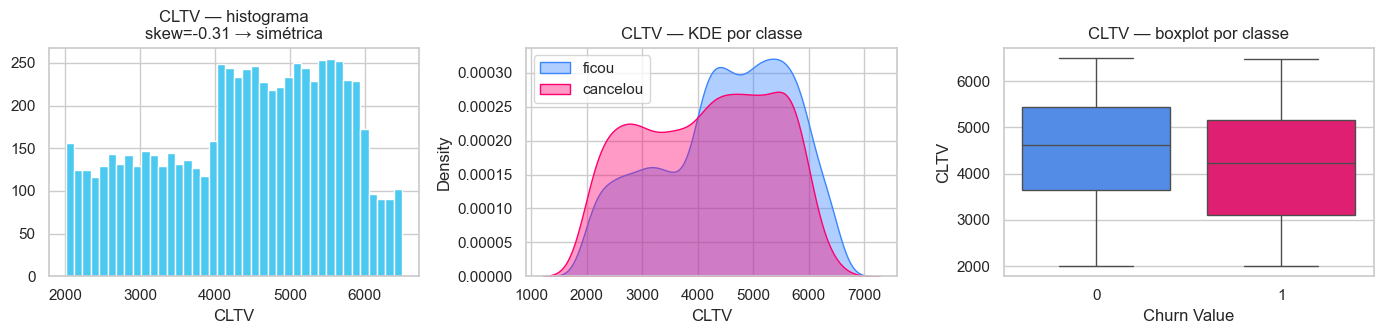

INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


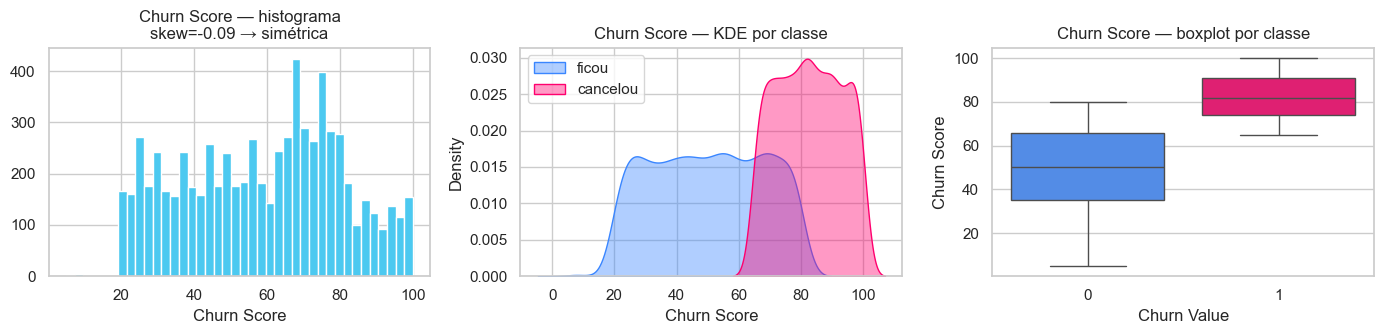

In [18]:
def classify_skew(s: float) -> str:
    if abs(s) < 0.5:
        return 'simétrica'
    elif s >= 0.5:
        return 'assimétrica positiva (cauda à direita)'
    else:
        return 'assimétrica negativa (cauda à esquerda)'

def plot_numeric(col: str, df_in: pd.DataFrame = df_eda) -> None:
    s = df_in[col].dropna()
    skew_val = s.skew()
    skew_label = classify_skew(skew_val)

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    # Histograma
    axes[0].hist(s, bins=40, color='#4cc9f0', edgecolor='white')
    axes[0].set_title(f'{col} — histograma\nskew={skew_val:.2f} → {skew_label}')
    axes[0].set_xlabel(col)
    # KDE por classe
    for v, label, color in [(0, 'ficou', '#3a86ff'), (1, 'cancelou', '#ff006e')]:
        sub = df_in[df_in[TARGET_COLUMN] == v][col].dropna()
        sns.kdeplot(sub, ax=axes[1], fill=True, alpha=0.4, label=label, color=color)
    axes[1].set_title(f'{col} — KDE por classe'); axes[1].legend()
    # Boxplot por classe
    sns.boxplot(data=df_in, x=TARGET_COLUMN, y=col, ax=axes[2], palette=['#3a86ff', '#ff006e'])
    axes[2].set_title(f'{col} — boxplot por classe')
    plt.tight_layout(); plt.show()

for col in NUM_COLS:
    plot_numeric(col)

### 6.1 Tabela consolidada de simetria

In [19]:
skew_table = pd.DataFrame({
    'skew': [df_eda[c].skew() for c in NUM_COLS],
    'kurtosis': [df_eda[c].kurtosis() for c in NUM_COLS],
    'mean': [df_eda[c].mean() for c in NUM_COLS],
    'median': [df_eda[c].median() for c in NUM_COLS],
    'std': [df_eda[c].std() for c in NUM_COLS],
}, index=NUM_COLS).round(3)
skew_table['classification'] = skew_table['skew'].apply(classify_skew)
skew_table

,skew,kurtosis,mean,median,std,classification
Tenure Months,0.240,-1.387,32.371,29.000,24.559,simétrica
Monthly Charges,-0.221,-1.257,64.762,70.350,30.090,simétrica
Total Charges,0.962,-0.232,2283.300,1397.475,2266.771,assimétrica positiva (cauda à direita)
CLTV,-0.312,-0.934,4400.296,4527.000,1183.057,simétrica
Churn Score,-0.090,-1.006,58.699,61.000,21.525,simétrica


## 7. Análise das categóricas

Para cada coluna: distribuição global + taxa de churn por nível (o que importa pra modelagem). Categóricas de identificação ou alta cardinalidade vão para a seção 8 (geo).

In [20]:
# Categóricas com cardinalidade modelável.
CAT_COLS = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Paperless Billing', 'Payment Method',
]
print('Categóricas analisadas:', len(CAT_COLS))

Categóricas analisadas: 16


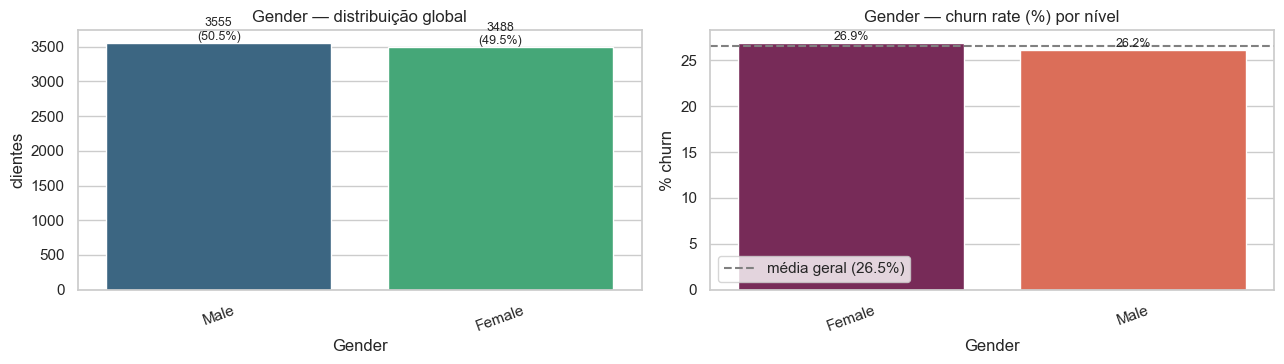

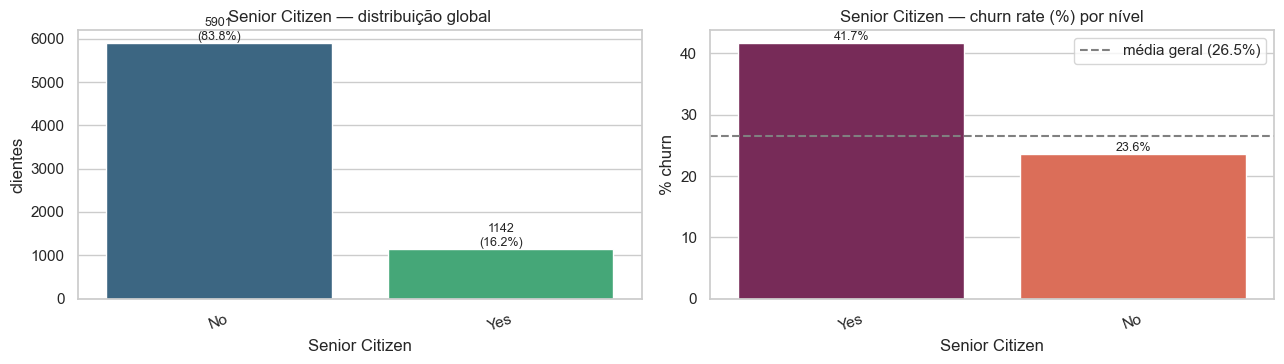

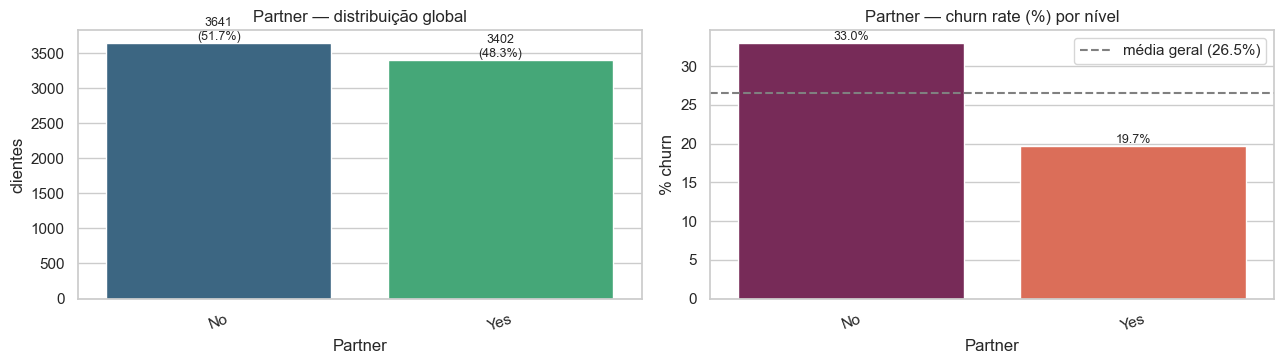

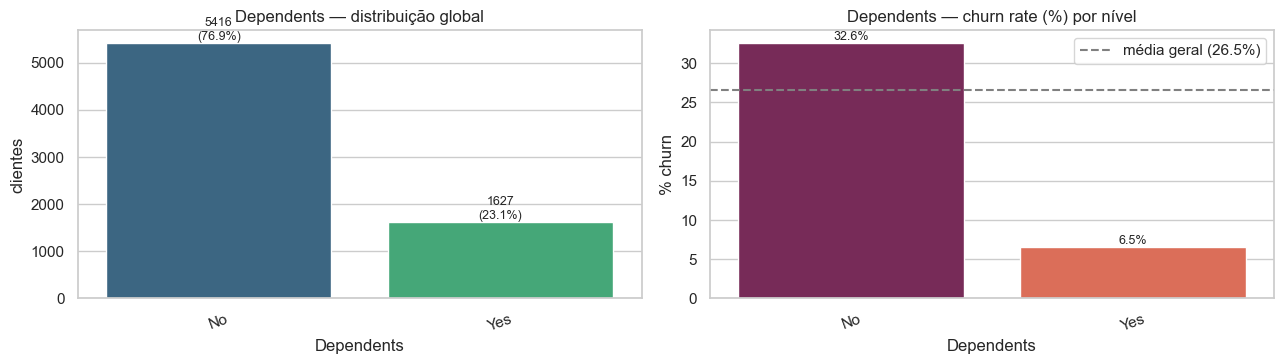

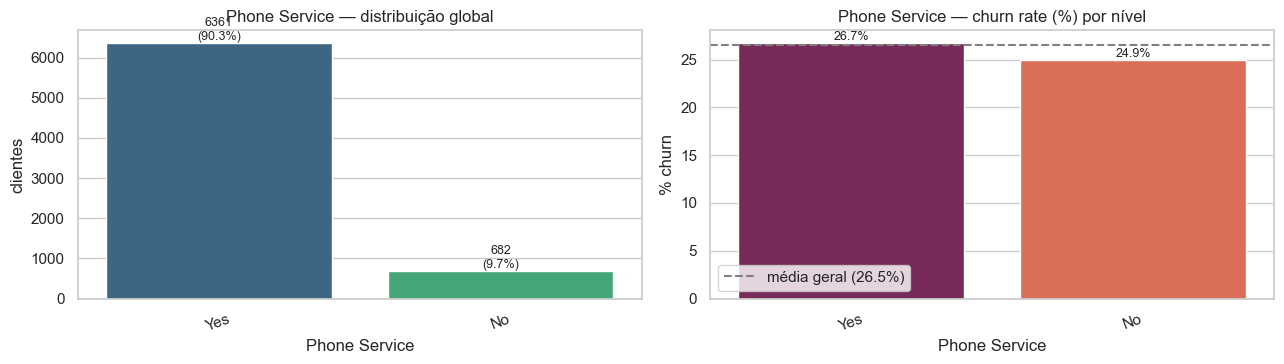

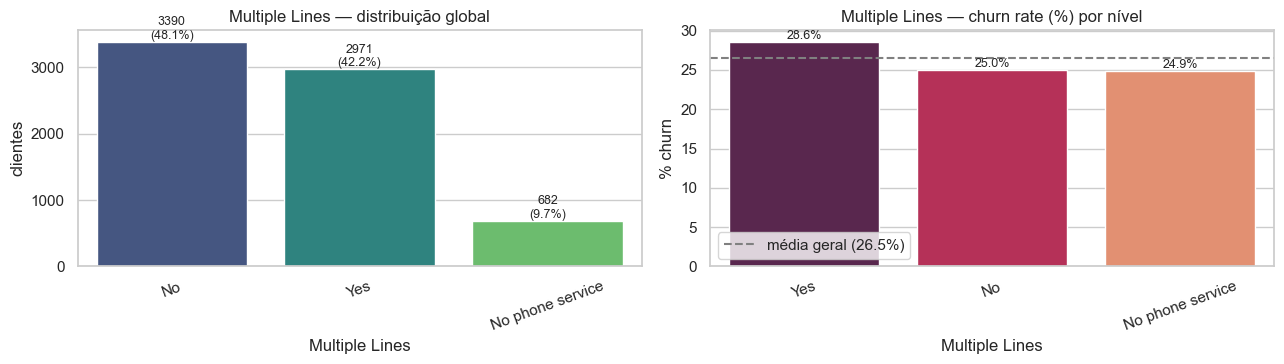

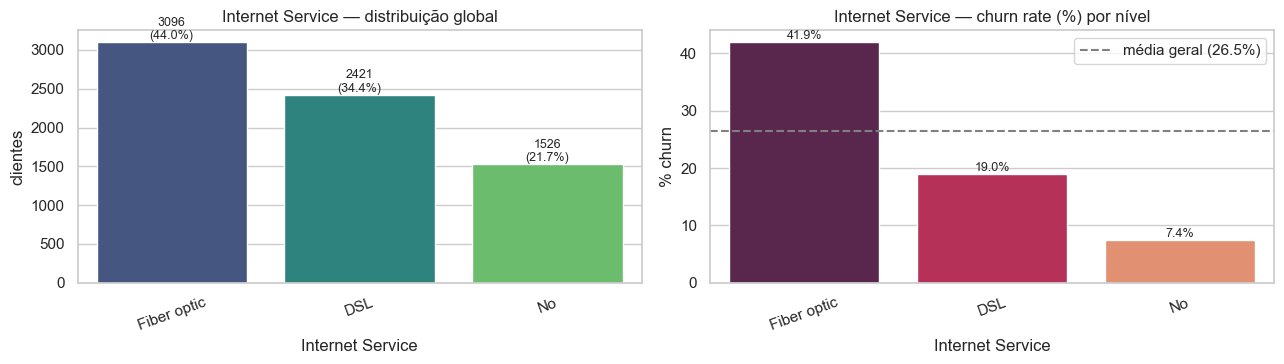

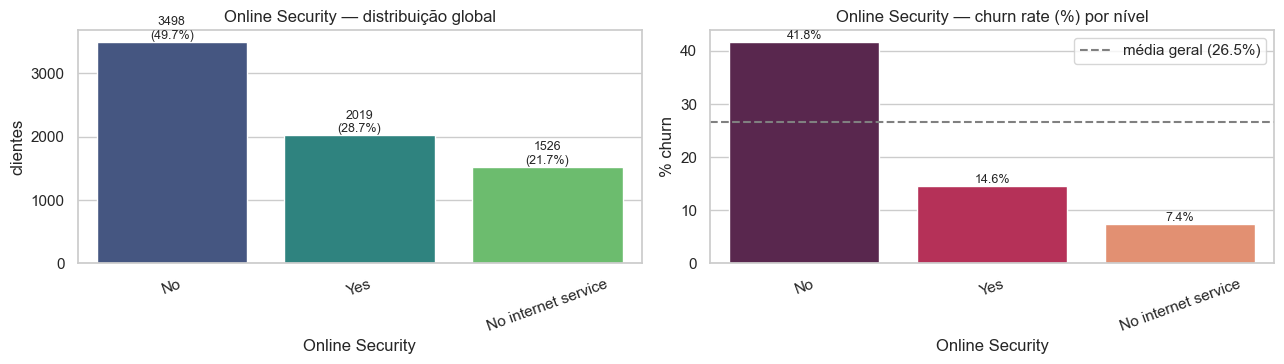

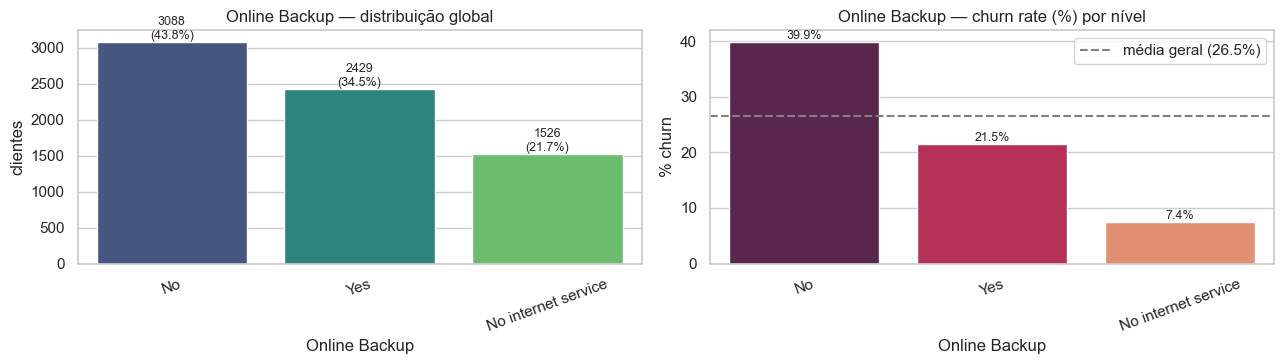

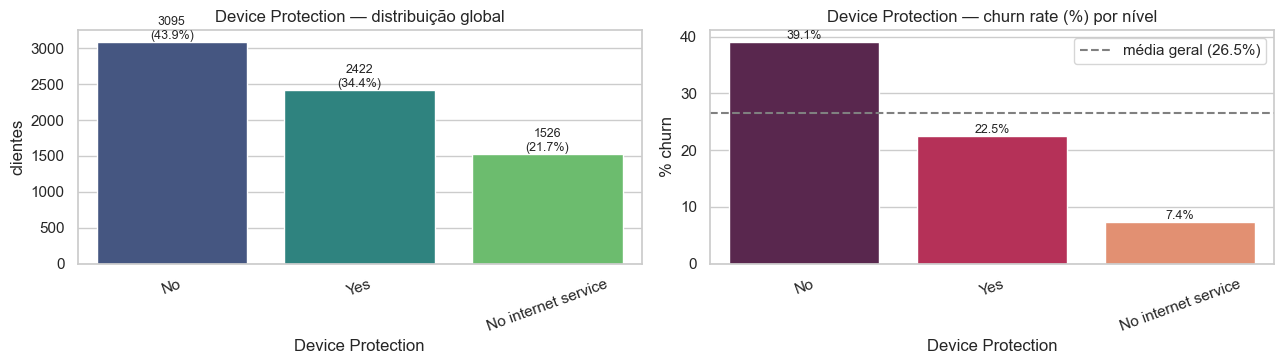

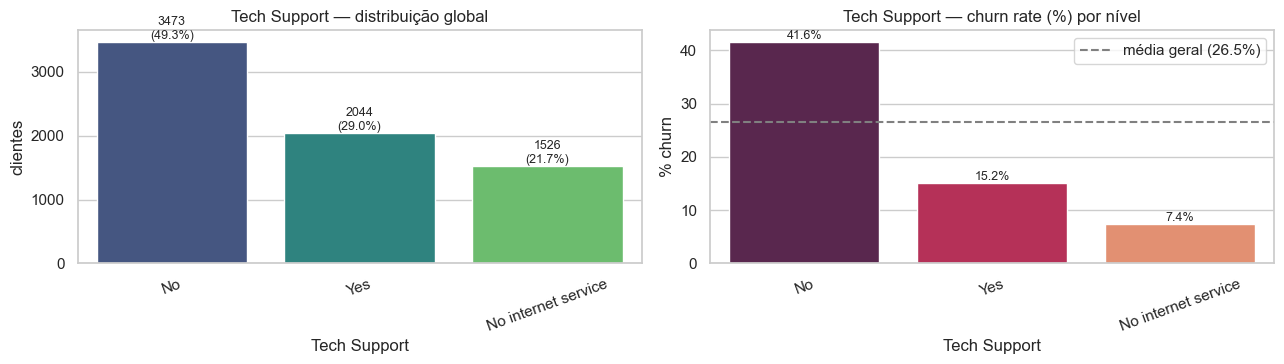

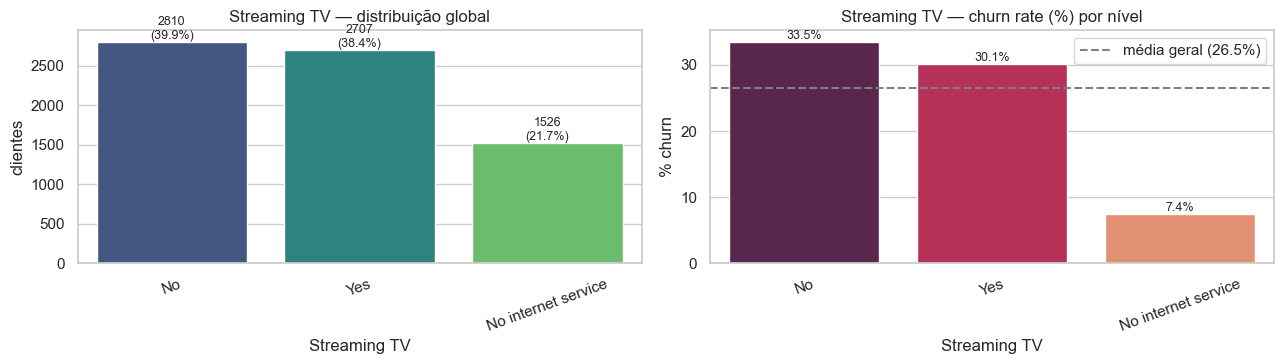

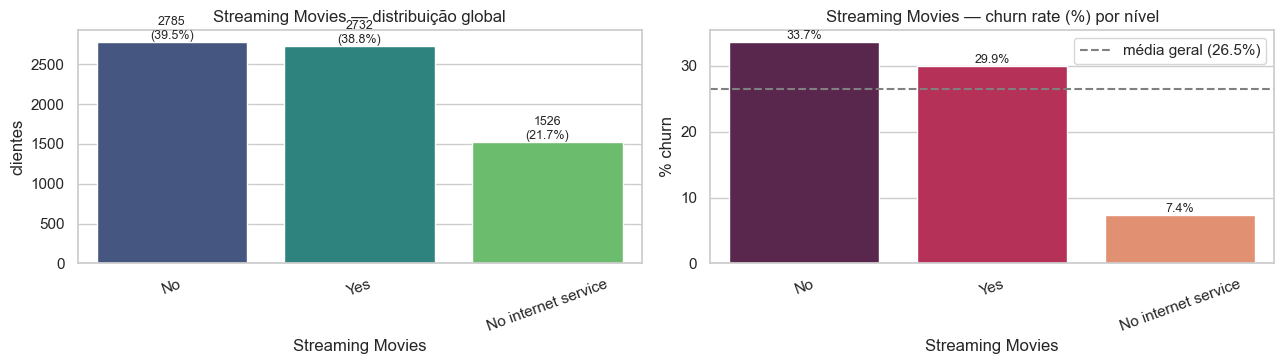

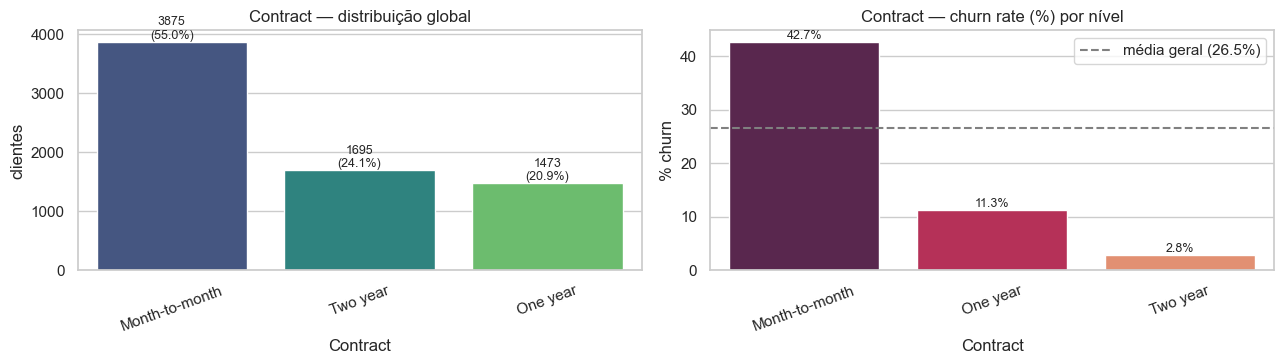

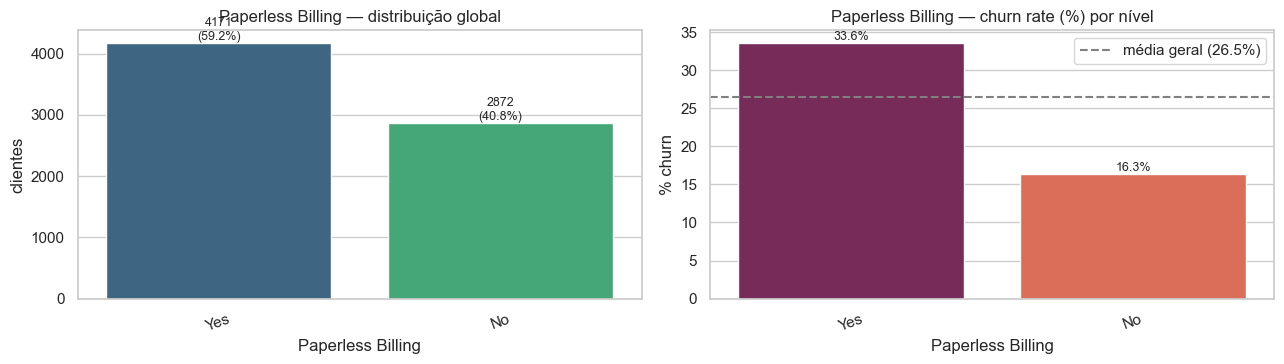

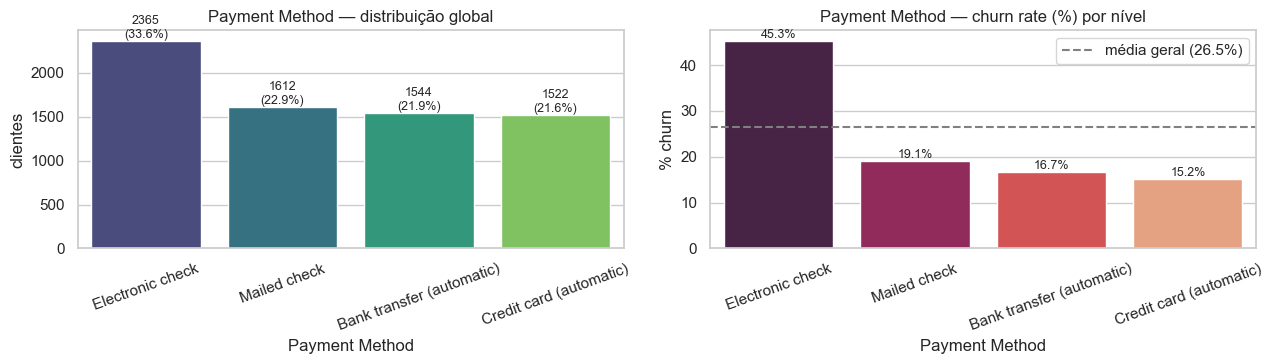

In [21]:
def plot_categorical(col: str, df_in: pd.DataFrame = df_eda) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

    # 1. Distribuição
    counts = df_in[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette='viridis')
    axes[0].set_title(f'{col} — distribuição global')
    axes[0].set_ylabel('clientes')
    for p, val in zip(axes[0].patches, counts.values):
        axes[0].annotate(f'{val}\n({val/len(df_in)*100:.1f}%)',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=9)
    axes[0].tick_params(axis='x', rotation=20)

    # 2. Churn rate por nível
    churn_rate = df_in.groupby(col)[TARGET_COLUMN].mean().sort_values(ascending=False) * 100
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[1], palette='rocket')
    axes[1].axhline(df_in[TARGET_COLUMN].mean() * 100, ls='--', color='gray', label=f'média geral ({df_in[TARGET_COLUMN].mean()*100:.1f}%)')
    axes[1].set_title(f'{col} — churn rate (%) por nível')
    axes[1].set_ylabel('% churn')
    for p, val in zip(axes[1].patches, churn_rate.values):
        axes[1].annotate(f'{val:.1f}%',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=9)
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].legend()
    plt.tight_layout(); plt.show()

for col in CAT_COLS:
    plot_categorical(col)

### 7.1 Tabela consolidada — churn rate por categoria

In [22]:
rows = []
for col in CAT_COLS:
    rates = df_eda.groupby(col)[TARGET_COLUMN].mean().sort_values(ascending=False) * 100
    rows.append({
        'feature': col,
        'n_levels': df_eda[col].nunique(),
        'max_churn_rate': rates.max(),
        'min_churn_rate': rates.min(),
        'spread_pp': rates.max() - rates.min(),
        'top_level': rates.idxmax(),
        'bottom_level': rates.idxmin(),
    })
summary_cat = pd.DataFrame(rows).sort_values('spread_pp', ascending=False).round(2)
summary_cat

,feature,n_levels,max_churn_rate,min_churn_rate,spread_pp,top_level,bottom_level
13,Contract,3,42.71,2.83,39.88,Month-to-month,Two year
6,Internet Service,3,41.89,7.40,34.49,Fiber optic,No
7,Online Security,3,41.77,7.40,34.36,No,No internet service
10,Tech Support,3,41.64,7.40,34.23,No,No internet service
8,Online Backup,3,39.93,7.40,32.52,No,No internet service
9,Device Protection,3,39.13,7.40,31.72,No,No internet service
15,Payment Method,4,45.29,15.24,30.04,Electronic check,Credit card (automatic)
12,Streaming Movies,3,33.68,7.40,26.28,No,No internet service
11,Streaming TV,3,33.52,7.40,26.12,No,No internet service
3,Dependents,2,32.55,6.52,26.04,No,Yes


## 8. Geográficas

Country, State, City, Zip Code, Latitude, Longitude — tratadas em bloco para inspecionar variabilidade real.

In [23]:
geo_cards = pd.Series({
    'Country': df['Country'].nunique(),
    'State': df['State'].nunique(),
    'City': df['City'].nunique(),
    'Zip Code': df['Zip Code'].nunique(),
    'Lat Long': df['Lat Long'].nunique(),
}, name='n_unique')
print('Cardinalidade das colunas geográficas:')
print(geo_cards)
print('\nValor único de Country:', df['Country'].unique())
print('Valor único de State:', df['State'].unique())

Cardinalidade das colunas geográficas:
Country        1
State          1
City        1129
Zip Code    1652
Lat Long    1652
Name: n_unique, dtype: int64

Valor único de Country: ['United States']
Valor único de State: ['California']


### 8.1 Top 15 cidades por número de clientes

In [24]:
top_cities = (
    df.groupby('City').agg(n=('CustomerID', 'count'), churn_rate=(TARGET_COLUMN, 'mean'))
    .sort_values('n', ascending=False).head(15)
)
top_cities['churn_rate'] = (top_cities['churn_rate'] * 100).round(2)
top_cities

,n,churn_rate
City,,
Los Angeles,305,29.51
San Diego,150,33.33
San Jose,112,25.89
Sacramento,108,24.07
San Francisco,104,29.81
Fresno,64,25.00
Long Beach,60,25.00
Oakland,52,25.00
Stockton,44,27.27


### 8.2 Latitude / Longitude — distribuição

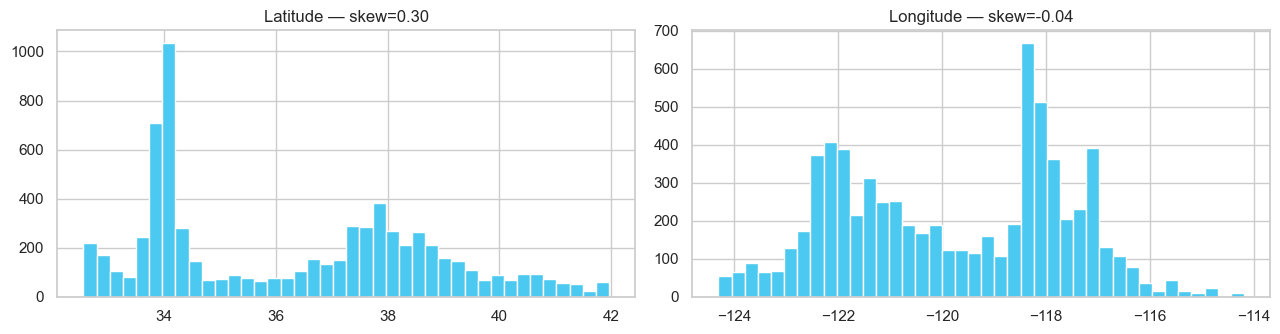

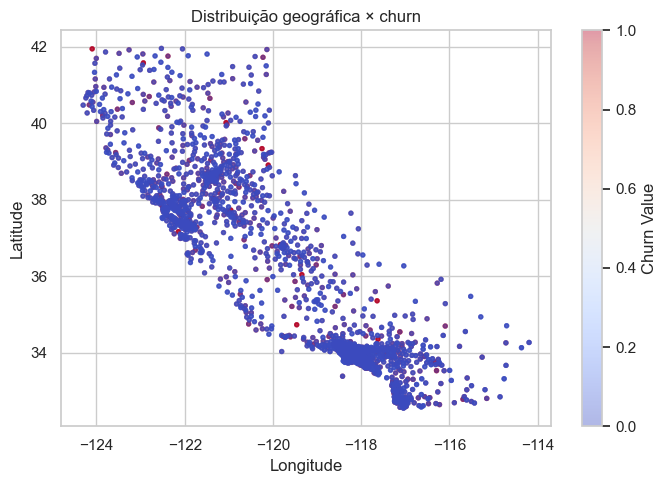

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].hist(df['Latitude'], bins=40, color='#4cc9f0', edgecolor='white')
axes[0].set_title(f'Latitude — skew={df["Latitude"].skew():.2f}')
axes[1].hist(df['Longitude'], bins=40, color='#4cc9f0', edgecolor='white')
axes[1].set_title(f'Longitude — skew={df["Longitude"].skew():.2f}')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(df['Longitude'], df['Latitude'], c=df[TARGET_COLUMN], cmap='coolwarm', alpha=0.4, s=8)
ax.set_title('Distribuição geográfica × churn')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.colorbar(scatter, ax=ax, label='Churn Value')
plt.tight_layout(); plt.show()

## 9. Outliers nas numéricas (regra IQR)

Critério: valor abaixo de Q1 − 1,5·IQR ou acima de Q3 + 1,5·IQR.

In [26]:
def iqr_outliers(s: pd.Series) -> dict:
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_lo = (s < lo).sum(); n_hi = (s > hi).sum()
    return {'n_low': n_lo, 'n_high': n_hi, 'pct_outlier': (n_lo + n_hi) / len(s) * 100, 'lower_bound': lo, 'upper_bound': hi}

out = pd.DataFrame({c: iqr_outliers(df_eda[c]) for c in NUM_COLS}).T
out['pct_outlier'] = out['pct_outlier'].round(2)
out

,n_low,n_high,pct_outlier,lower_bound,upper_bound
Tenure Months,0.0,0.0,0.0,-60.00000,124.00000
Monthly Charges,0.0,0.0,0.0,-46.02500,171.37500
Total Charges,0.0,0.0,0.0,-4688.48125,8884.66875
CLTV,0.0,0.0,0.0,601.75000,8247.75000
Churn Score,0.0,0.0,0.0,-12.50000,127.50000


## 10. Correlação com `Churn Value`

- **Numéricas:** Pearson (linear) e Spearman (monotônica).
- **Categóricas:** Cramér's V (medida de associação para tabelas de contingência).

### 10.1 Numéricas — Pearson e Spearman

In [27]:
num_for_corr = NUM_COLS + ['Latitude', 'Longitude', 'Zip Code']
corr_pearson = df_eda[num_for_corr].apply(lambda c: c.corr(df_eda[TARGET_COLUMN], method='pearson'))
corr_spearman = df_eda[num_for_corr].apply(lambda c: c.corr(df_eda[TARGET_COLUMN], method='spearman'))
corr_table = pd.DataFrame({'pearson': corr_pearson, 'spearman': corr_spearman}).round(4)
corr_table['abs_max'] = corr_table.abs().max(axis=1)
corr_table.sort_values('abs_max', ascending=False)

,pearson,spearman,abs_max
Churn Score,0.6649,0.6756,0.6756
Tenure Months,-0.3522,-0.3671,0.3671
Total Charges,-0.1995,-0.2322,0.2322
Monthly Charges,0.1934,0.1847,0.1934
CLTV,-0.1275,-0.1236,0.1275
Longitude,0.0046,0.0058,0.0058
Latitude,-0.0034,-0.0009,0.0034
Zip Code,0.0033,0.0018,0.0033


### 10.2 Heatmap das numéricas (Pearson)

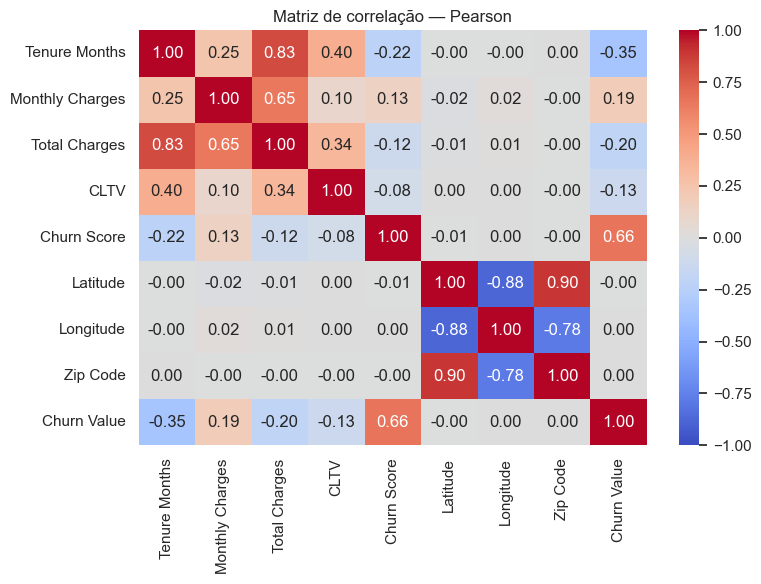

In [28]:
corr_matrix = df_eda[num_for_corr + [TARGET_COLUMN]].corr(method='pearson')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriz de correlação — Pearson')
plt.tight_layout(); plt.show()

### 10.3 Categóricas — Cramér's V

In [29]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    contingency = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(contingency)[0]
    n = contingency.values.sum()
    r, k = contingency.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1)))) if min(r, k) > 1 else 0.0

cramer_table = pd.Series(
    {col: cramers_v(df_eda[col], df_eda[TARGET_COLUMN]) for col in CAT_COLS},
    name="Cramér's V",
).sort_values(ascending=False).round(4)
cramer_table.to_frame()

,Cramér's V
Contract,0.4101
Online Security,0.3474
Tech Support,0.3429
Internet Service,0.3225
Payment Method,0.3034
Online Backup,0.2923
Device Protection,0.2816
Dependents,0.2482
Streaming Movies,0.2310
Streaming TV,0.2305


### 10.4 Ranking final — todas as features (sem leakage)

Combina |Pearson|/|Spearman| (numéricas) e Cramér's V (categóricas) em uma única tabela, excluindo as colunas de leakage e identificadores.

In [30]:
EXCLUDE = set(LEAKAGE_COLUMNS) | {TARGET_COLUMN, 'CustomerID', 'Count', 'Lat Long', 'Country', 'State'}

rank_rows = []
for col in num_for_corr:
    if col in EXCLUDE: continue
    val = max(abs(corr_pearson[col]), abs(corr_spearman[col]))
    rank_rows.append({'feature': col, 'type': 'numeric', 'score': val, 'metric': 'max(|pearson|,|spearman|)'})
for col, v in cramer_table.items():
    if col in EXCLUDE: continue
    rank_rows.append({'feature': col, 'type': 'categorical', 'score': float(v), 'metric': "Cramér's V"})

ranking = pd.DataFrame(rank_rows).sort_values('score', ascending=False).reset_index(drop=True)
ranking['score'] = ranking['score'].round(4)
ranking

,feature,type,score,metric
0,Contract,categorical,0.4101,Cramér's V
1,Tenure Months,numeric,0.3671,"max(|pearson|,|spearman|)"
2,Online Security,categorical,0.3474,Cramér's V
3,Tech Support,categorical,0.3429,Cramér's V
4,Internet Service,categorical,0.3225,Cramér's V
5,Payment Method,categorical,0.3034,Cramér's V
6,Online Backup,categorical,0.2923,Cramér's V
7,Device Protection,categorical,0.2816,Cramér's V
8,Dependents,categorical,0.2482,Cramér's V
9,Total Charges,numeric,0.2322,"max(|pearson|,|spearman|)"


## 11. Insights consolidados

> **Sumário executivo:** dados de qualidade alta (0 duplicatas, 0 outliers IQR
> nas numéricas, apenas 11 linhas problemáticas em `Total Charges`).
> **Três colunas são vazamento confirmado** e devem sair antes do treino.
> O target é desbalanceado (~26,5%) e o sinal mais forte vem de **tipo de
> contrato + tempo de casa + bundle de add-ons + método de pagamento**.

### 11.1 Qualidade dos dados

- **Shape conferido:** 7.043 × 33, sem linhas duplicadas e sem `CustomerID` duplicado.
- **`Total Charges` em `object`:** 11 linhas têm `' '` (string em branco). Todos os 11
  registros têm `Tenure Months == 0` e `Churn Value == 0` — são clientes novos
  ainda sem cobrança total. **Decisão para o 02_data_prep:** converter para
  `float` e imputar `0.0` (consistente com `Tenure == 0`).
- **Nulls:** somente `Churn Reason` tem nulls (73,46% = exatamente os não-churners
  — confirma que é leak, ver 11.2).
- **Outliers (IQR):** 0% em todas as numéricas analisadas. Não há valores
  extremos espúrios — não vamos precisar de winsorização.

### 11.2 Vazamento de target (remoção obrigatória)

| Coluna | Evidência | Ação |
|---|---|---|
| `Churn Label` | Crosstab 1:1 com `Churn Value` (é o mesmo dado em texto) | **Drop** |
| `Churn Score` | AUC sozinho = **0,9417** (gerado por modelo IBM SPSS sobre o próprio target) | **Drop** |
| `Churn Reason` | 100% nulo quando `Churn Value == 0`; só preenchido pós-fato | **Drop** |
| `CLTV` | AUC sozinho = **0,5808** (sinal fraco, dentro do esperado para uma feature legítima) | **Manter** — útil, não é leak |

### 11.3 Geografia — descartar tudo

- `Country` = único valor (`United States`).
- `State` = único valor (`California`).
- `City`: 1.129 valores únicos. Top 15 cidades têm taxa de churn entre 7% e 33%,
  sem padrão sistemático e amostra pequena por cidade — não generaliza.
- `Zip Code`, `Latitude`, `Longitude`, `Lat Long`: correlações com o target
  todas abaixo de 0,01 (Pearson e Spearman). **Sem sinal.**
- **Decisão:** descartar todas as colunas geográficas no 02_data_prep.

### 11.4 Distribuições e simetria (numéricas)

| Coluna | skew | classificação |
|---|---|---|
| `Tenure Months` | 0,24 | simétrica (mas **bimodal**: massa de novos e antigos) |
| `Monthly Charges` | -0,22 | simétrica (também bimodal — separação clara DSL × Fiber) |
| `Total Charges` | **0,96** | **assimétrica positiva** (cauda à direita) |
| `CLTV` | -0,31 | simétrica |
| `Churn Score` | -0,09 | simétrica (mas é leak — não usar) |

`Total Charges` é a única candidata a transformação log no 02_data_prep, mas
como vamos escalar com `StandardScaler` e o MLP tem `BatchNorm` na entrada,
provavelmente não é necessário. Decisão revisitada após baseline.

### 11.5 Ranking de features (sem leakage e sem geo)

Combinando |Pearson|/|Spearman| (numéricas) com Cramér's V (categóricas):

| # | Feature | Tipo | Score |
|---|---|---|---|
| 1 | **Contract** | cat | 0,4101 |
| 2 | **Tenure Months** | num | 0,3671 |
| 3 | Online Security | cat | 0,3474 |
| 4 | Tech Support | cat | 0,3429 |
| 5 | Internet Service | cat | 0,3225 |
| 6 | Payment Method | cat | 0,3034 |
| 7 | Online Backup | cat | 0,2923 |
| 8 | Device Protection | cat | 0,2816 |
| 9 | Dependents | cat | 0,2482 |
| 10 | Total Charges | num | 0,2322 |
| ... | (Streaming Movies/TV, Monthly Charges, Paperless Billing, Senior, Partner, CLTV) | mix | 0,13–0,23 |
| — | **Multiple Lines** (0,04), **Phone Service** (0,01), **Gender** (0,01) | cat | sem sinal |

### 11.6 Insights de negócio

- **Perfil de alto risco** (combinando os top sinais):
  *Contrato month-to-month* (42,71% churn) + *sem Online Security* (41,77%) +
  *sem Tech Support* (41,64%) + *Fiber Optic* (41,89%) + *Electronic check*
  (45,29%) + *sem dependents* + *senior citizen*.
- **Perfil de baixo risco** é o espelho:
  *Two-year contract* (2,83% churn) + *add-ons contratados* + *Credit card
  automatic* (15,24%) + *com dependents* (6,52%).
- **`Gender` é praticamente ortogonal ao churn** (Cramér's V = 0,008;
  Female 26,92% vs Male 26,16%). **Não tem valor preditivo, mas será mantido
  na fase 02 para suportar a análise de viés no Model Card** (fase 5).
- **`Phone Service` e `Multiple Lines`** têm sinal muito fraco (~0,01–0,04).
  São candidatos a descarte no 02_data_prep — confirmar com o ablation
  do baseline antes de remover definitivamente.

### 11.7 Implicações para o pré-processamento (entrega no 02_data_prep)

- **Drop:** identificadores (`CustomerID`, `Count`), todas as geográficas
  (`Country`, `State`, `City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude`),
  todos os leakers (`Churn Label`, `Churn Score`, `Churn Reason`).
- **Manter:** `CLTV` (sinal fraco mas legítimo).
- **Total Charges:** coercion para `float` e imputação `= 0.0` para os 11
  casos de tenure=0.
- **Encoding:** binárias (`Yes`/`No`) → 0/1; multi-categóricas (`Contract`,
  `Internet Service`, `Payment Method`, multi-níveis com "No internet service")
  → OneHot.
- **Numéricas:** `StandardScaler` no pipeline.
- **Class imbalance:** `class_weight='balanced'` no LogReg, `pos_weight` no MLP.